Importing Packages

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()




Loading and transforming the data to required form(date as index)

In [15]:
raw_data = pd.read_csv("./datasets/Index2018.csv")
comp_df = raw_data.copy()
comp_df.date = pd.to_datetime(comp_df.date, dayfirst=True)
comp_df.set_index("date", inplace=True)
comp_df=comp_df.asfreq("b")
comp_df = comp_df.fillna(method="ffill")

C:\Users\USER\AppData\Local\Temp\ipykernel_11868\2213365833.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  comp_df = comp_df.fillna(method="ffill")


Removing surplus from data

In [16]:
comp_df["market_Price"] = comp_df.spx
comp_df.head()
del comp_df ["dax"]
del comp_df["spx"]
del comp_df["ftse"]
del comp_df["nikkei"]


Splitting remaining Data (using iloc function)

In [ ]:

size = int(len(comp_df) * 0.8)
df,test_df = comp_df.iloc[:size],comp_df.iloc[size:]

 

Generating White Noise

In [18]:
wn = np.random.normal(loc = df.market_Price.mean(),scale = df.market_Price.std(),size = len(df))
df["wn"] = wn

C:\Users\USER\AppData\Local\Temp\ipykernel_11868\3911038706.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["wn"] = wn


Generating Random Walk data

In [19]:
iAmRaw = pd.read_csv("./datasets/RandWalk.csv")
rw = iAmRaw.copy()
rw.date = pd.to_datetime(rw.date, dayfirst=True)
rw.set_index("date",inplace=True)
rw.asfreq("b")
df["rw"] = rw

C:\Users\USER\AppData\Local\Temp\ipykernel_11868\2414077386.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["rw"] = rw


Comparing Random-walk with White-noise (Graph)

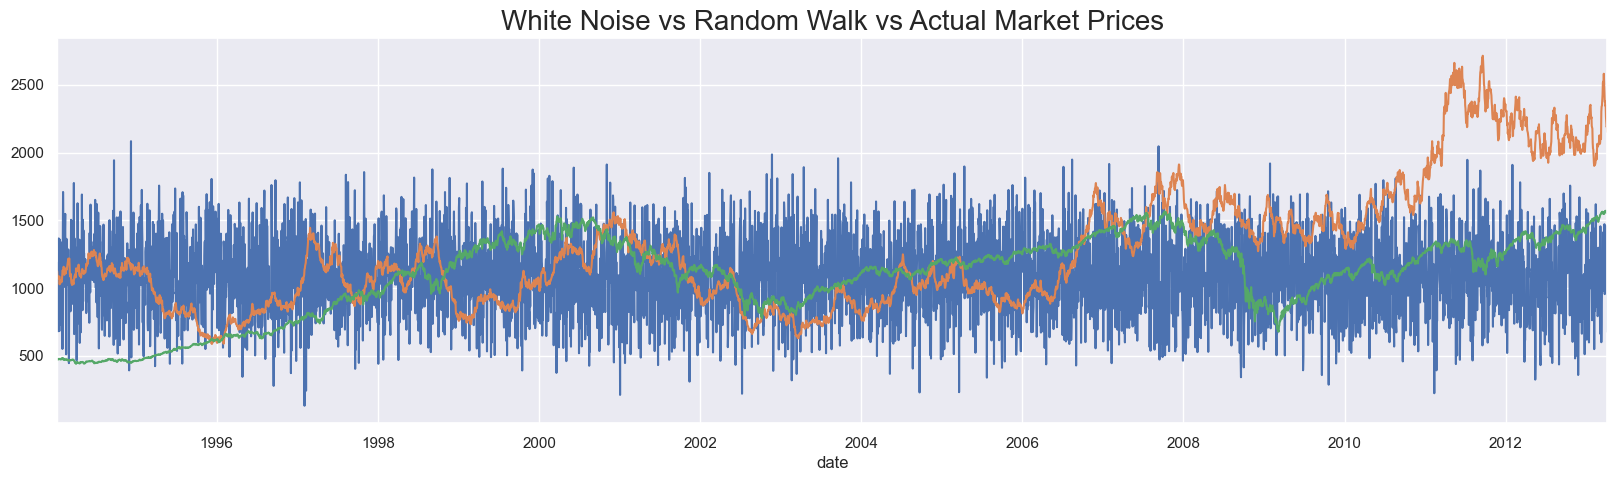

In [20]:

df.wn.plot(figsize=(20,5))
df.rw.plot(figsize=(20,5))
df.market_Price.plot(figsize=(20,5))
plt.title("White Noise vs Random Walk vs Actual Market Prices", size = 20)
plt.show()

Testing for Stationarity

In [21]:
import statsmodels.tsa.stattools as sts
sts.adfuller(df.market_Price)

(np.float64(-1.7369847452352436),
 np.float64(0.4121645696770623),
 18,
 5002,
 {'1%': np.float64(-3.431658008603046),
  '5%': np.float64(-2.862117998412982),
  '10%': np.float64(-2.567077669247375)},
 np.float64(39904.880607487445))

In [22]:
sts.adfuller(df.wn)

(np.float64(-51.36300444989087),
 0.0,
 1,
 5019,
 {'1%': np.float64(-3.4316535759402753),
  '5%': np.float64(-2.8621160400844468),
  '10%': np.float64(-2.567076626752987)},
 np.float64(70700.87353974358))

Testing for Seasonality

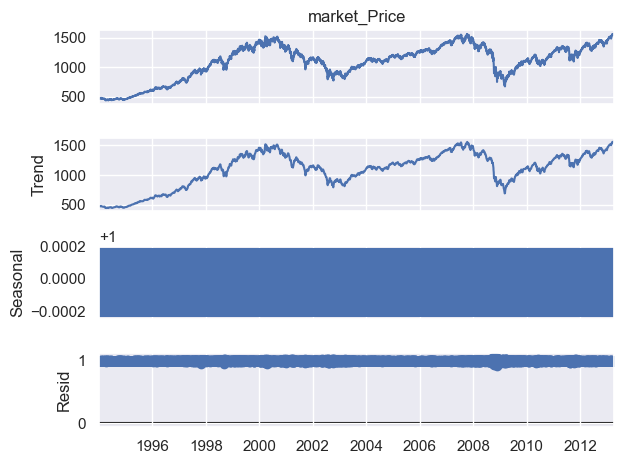

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose
sea_dec_add = seasonal_decompose(df.market_Price, model="additive")
sea_dec_mul = seasonal_decompose(df.market_Price, model="multiplicative")
sea_dec_mul.plot()
plt.show()

Testing for Auto-correlation (using the ACF)

In [24]:

import statsmodels.graphics.tsaplots as sgt

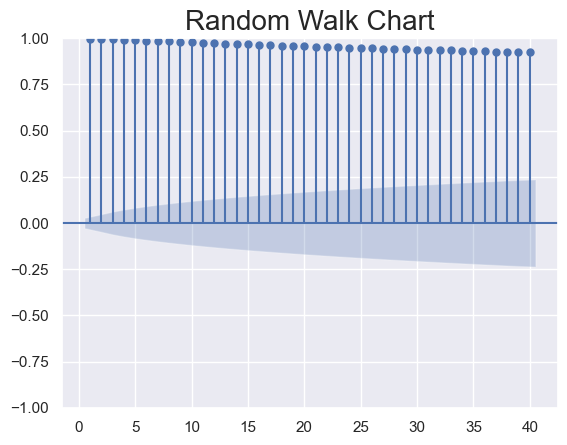

In [25]:
sgt.plot_acf(df.rw, lags=40, zero=False )
plt.title("Random Walk Chart", size=20)
plt.show()

Test for Partial Auto-correlation (using the PACF)

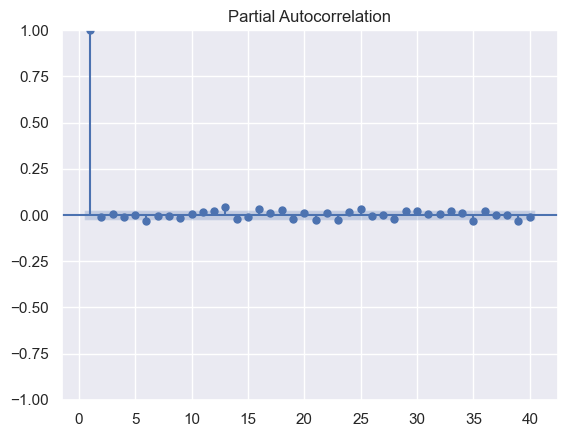

In [26]:
sgt.plot_pacf(df.rw, lags=40, zero=False, method="ols")
plt.show()